# DriftGuard — Dataset Validation & Exploratory Data Analysis

## About This Project

I am building DriftGuard to study how machine learning models behave when the underlying data distribution changes over time.

In this project, I focus on adaptive classification for streaming data. I use Gaussian Naive Bayes and K-Nearest Neighbors (KNN) as the classification models, Page-Hinkley for detecting changes in model performance, and model-specific adaptation strategies to respond to detected drift.

My goal is not only to build classifiers, but to understand whether detecting and responding to concept drift can help maintain model performance over a changing data stream.

This notebook is the first step of the project. Before designing the streaming and adaptation mechanisms, I will first validate and understand the dataset.

## What I Will Do in This Notebook

I will:

- Load the Electricity dataset
- Understand its structure and features
- Validate data quality
- Examine the target distribution
- Study the sequential nature of the data
- Explore feature distributions
- Identify preprocessing requirements
- Make evidence-based decisions for the streaming setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
from scipy.io import arff
import pandas as pd

data_path = Path("../data/raw/elecNormNew.arff")

data, metadata = arff.loadarff(data_path)

df = pd.DataFrame(data)

df.head()

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
0,0.0,b'2',0.000000,0.056443,0.439155,0.003467,0.422915,0.414912,b'UP'
1,0.0,b'2',0.021277,0.051699,0.415055,0.003467,0.422915,0.414912,b'UP'
2,0.0,b'2',0.042553,0.051489,0.385004,0.003467,0.422915,0.414912,b'UP'
3,0.0,b'2',0.063830,0.045485,0.314639,0.003467,0.422915,0.414912,b'UP'
4,0.0,b'2',0.085106,0.042482,0.251116,0.003467,0.422915,0.414912,b'DOWN'


In [4]:
df.shape

(45312, 9)

In [5]:
df.dtypes

date         float64
day           object
period       float64
nswprice     float64
nswdemand    float64
vicprice     float64
vicdemand    float64
transfer     float64
class         object
dtype: object

In [6]:
df.columns.tolist()

['date',
 'day',
 'period',
 'nswprice',
 'nswdemand',
 'vicprice',
 'vicdemand',
 'transfer',
 'class']

In [8]:
# Display the structure, data types, and non-null counts of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45312 entries, 0 to 45311
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       45312 non-null  float64
 1   day        45312 non-null  object 
 2   period     45312 non-null  float64
 3   nswprice   45312 non-null  float64
 4   nswdemand  45312 non-null  float64
 5   vicprice   45312 non-null  float64
 6   vicdemand  45312 non-null  float64
 7   transfer   45312 non-null  float64
 8   class      45312 non-null  object 
dtypes: float64(7), object(2)
memory usage: 3.1+ MB


In [9]:
# Check the number of missing values in each column
print("\nMissing values:")
print(df.isna().sum())


Missing values:
date         0
day          0
period       0
nswprice     0
nswdemand    0
vicprice     0
vicdemand    0
transfer     0
class        0
dtype: int64


In [11]:
# Check whether any complete rows are duplicated
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
# Count the observations belonging to each target class
print("Target distribution:")
print(df["class"].value_counts())

Target distribution:
class
b'DOWN'    26075
b'UP'      19237
Name: count, dtype: int64


In [15]:
#Show the unique values stored in the day column
print("Day values:")
print(df["day"].unique())

# Show the unique values stored in the target column
print("\nClass values:")
print(df["class"].unique())

# Count the observations for each target class
print("\nClass distribution:")
print(df["class"].value_counts())

Day values:
[b'2' b'3' b'4' b'5' b'6' b'7' b'1']

Class values:
[b'UP' b'DOWN']

Class distribution:
class
b'DOWN'    26075
b'UP'      19237
Name: count, dtype: int64


In [16]:
# Display the first and last timestamps to understand the temporal coverage of the stream
print("Date range:")
print(df["date"].iloc[0], "→", df["date"].iloc[-1])

# Count how many observations occur for each day category
print("\nObservations by day:")
print(df["day"].value_counts().sort_index())

# Inspect the first few time-period values to understand their ordering
print("\nFirst 20 periods:")
print(df["period"].head(20).to_list())

# Check whether the period values remain within a consistent daily range
print("\nPeriod range:")
print(df["period"].min(), "→", df["period"].max())

Date range:
0.0 → 0.9158

Observations by day:
day
b'1'    6432
b'2'    6480
b'3'    6480
b'4'    6480
b'5'    6480
b'6'    6480
b'7'    6480
Name: count, dtype: int64

First 20 periods:
[0.0, 0.021277, 0.042553, 0.06383, 0.085106, 0.106383, 0.12766, 0.148936, 0.170213, 0.191489, 0.212766, 0.234043, 0.255319, 0.276596, 0.297872, 0.319149, 0.340426, 0.361702, 0.382979, 0.404255]

Period range:
0.0 → 1.0


In [17]:
# Show summary statistics for the numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
date,45312.0,0.499080,0.340308,0.0,0.031934,0.456329,0.880547,1.0
period,45312.0,0.500000,0.294756,0.0,0.250000,0.500000,0.750000,1.0
nswprice,45312.0,0.057868,0.039991,0.0,0.035127,0.048652,0.074336,1.0
nswdemand,45312.0,0.425418,0.163323,0.0,0.309134,0.443693,0.536001,1.0
vicprice,45312.0,0.003467,0.010213,0.0,0.002277,0.003467,0.003467,1.0
vicdemand,45312.0,0.422915,0.120965,0.0,0.372346,0.422915,0.469252,1.0
transfer,45312.0,0.500526,0.153373,0.0,0.414912,0.414912,0.605702,1.0


In [18]:
# Create a working copy so the original loaded dataset remains unchanged
df_clean = df.copy()

# Convert the byte values in the day column into normal strings
df_clean["day"] = df_clean["day"].str.decode("utf-8")

# Convert the byte values in the target column into normal strings
df_clean["class"] = df_clean["class"].str.decode("utf-8")

# Check that the categorical values were converted correctly
df_clean[["day", "class"]].head()

,day,class
0,2,UP
1,2,UP
2,2,UP
3,2,UP
4,2,DOWN


In [19]:
# Check the data types after converting the categorical columns
df_clean.dtypes

date         float64
day           object
period       float64
nswprice     float64
nswdemand    float64
vicprice     float64
vicdemand    float64
transfer     float64
class         object
dtype: object

## Understanding the Temporal Structure

### Why

I am building DriftGuard for a data-streaming problem, so the order in which observations arrive is important.

Before I design the streaming batches, I need to understand how the temporal information is represented in the dataset. This will help me distinguish the chronological order of the stream from the variables that may be used as model features.

### What I Will Check

I will examine the number of unique values and the ranges of the temporal columns. I will also verify how the observations are distributed across the different day categories.

This will help me make an informed decision about how temporal information should be handled later in the modeling pipeline.

In [20]:
# Check how many unique values are present in the date and period columns
print("Unique date values:", df_clean["date"].nunique())
print("Unique period values:", df_clean["period"].nunique())

# Check the range of the date and period values
print("\nDate range:", df_clean["date"].min(), "to", df_clean["date"].max())
print("Period range:", df_clean["period"].min(), "to", df_clean["period"].max())

# Count observations for each day category
print("\nObservations by day:")
print(df_clean["day"].value_counts().sort_index())

Unique date values: 933
Unique period values: 48

Date range: 0.0 to 1.0
Period range: 0.0 to 1.0

Observations by day:
day
1    6432
2    6480
3    6480
4    6480
5    6480
6    6480
7    6480
Name: count, dtype: int64


## Feature Behaviour by Target Class

### Why

I have confirmed the basic structure and quality of the dataset. I now want to understand whether the input features show different patterns for the two target classes, `UP` and `DOWN`.

This helps me assess whether the features contain useful classification information before I build the baseline models.

### What I Will Check

I will compare the numerical feature distributions across the two target classes.

I am mainly looking for:

- Features whose distributions differ between the classes
- Features with very similar distributions
- Features with limited variation
- Any unusual patterns that may require further investigation

I will use these observations as exploratory evidence rather than assuming that a visible difference guarantees predictive performance.

In [21]:
# Store the numerical predictor columns for feature-level analysis
numeric_features = [
    "date",
    "period",
    "nswprice",
    "nswdemand",
    "vicprice",
    "vicdemand",
    "transfer"
]

# Compare the average value of each numerical feature across the target classes
df_clean.groupby("class")[numeric_features].mean().T

class,DOWN,UP
date,0.500922,0.496583
period,0.460686,0.553289
nswprice,0.044838,0.075530
nswdemand,0.378574,0.488914
vicprice,0.002900,0.004235
vicdemand,0.398581,0.455898
transfer,0.516642,0.478682


### Feature Distributions by Class

### Why

Average values alone may hide differences in the distributions. I will therefore visualize each numerical feature for `UP` and `DOWN` observations.

This gives me a better understanding of how the classes differ and whether any feature appears to have limited or distinctive behaviour.

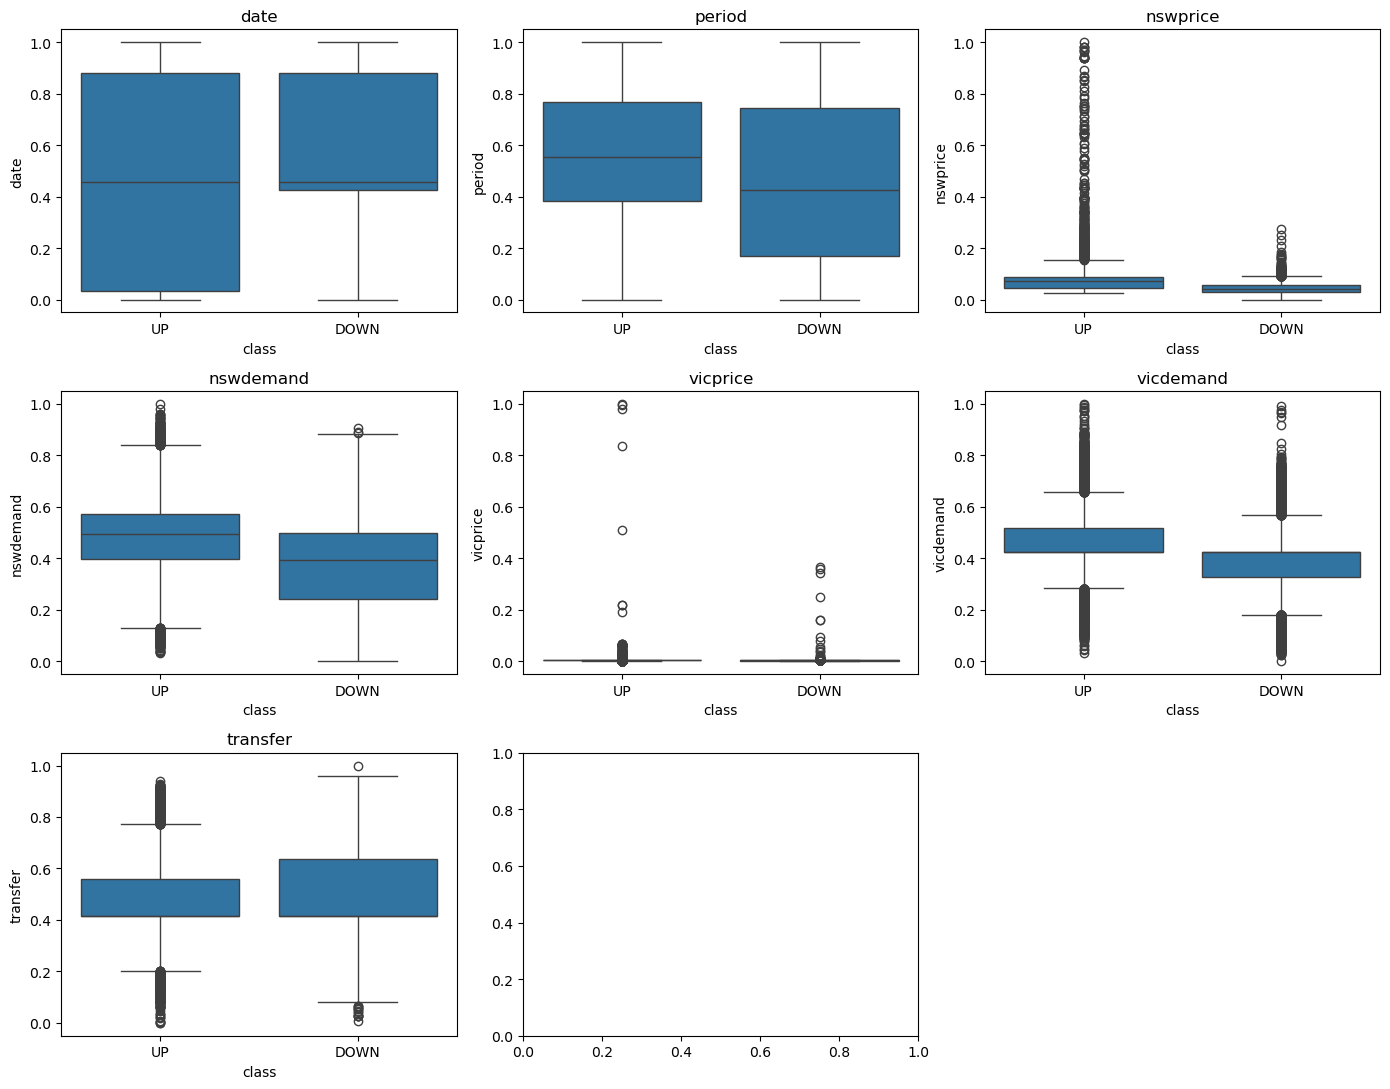

In [22]:
# Create a comparison plot for the numerical features across the two classes
fig, axes = plt.subplots(3, 3, figsize=(14, 11))

# Plot the distribution of each feature for UP and DOWN observations
for ax, feature in zip(axes.flat, numeric_features):
    sns.boxplot(data=df_clean, x="class", y=feature, ax=ax)
    ax.set_title(feature)

# Hide the unused subplot
axes.flat[-1].set_visible(False)

# Keep the plots properly spaced
plt.tight_layout()

# Save the figure as a project artifact
plt.savefig("../reports/figures/feature_class_comparison.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

## Correlation Between Numerical Features

### Why

I also want to understand how the numerical predictors relate to one another.

This is particularly relevant because Gaussian Naive Bayes assumes conditional independence between features given the class, while KNN uses distances between observations.

Strong correlation does not automatically mean that I should remove a feature. I will use this analysis to understand the dataset and revisit feature decisions during model evaluation.

In [23]:
# Calculate the correlation between the numerical predictor variables
feature_correlation = df_clean[numeric_features].corr()

# Display the correlation matrix
feature_correlation

,date,period,nswprice,nswdemand,vicprice,vicdemand,transfer
date,1.000000e+00,-1.331142e-15,-0.151428,0.066748,0.003225,0.055323,0.405012
period,-1.331142e-15,1.000000e+00,0.104155,0.445547,0.023245,0.192945,-0.116979
nswprice,-1.514277e-01,1.041553e-01,1.000000,0.304952,0.286072,0.307275,-0.275001
nswdemand,6.674768e-02,4.455472e-01,0.304952,1.000000,0.086393,0.668501,-0.267897
vicprice,3.224591e-03,2.324549e-02,0.286072,0.086393,1.000000,0.127553,-0.084166
vicdemand,5.532348e-02,1.929449e-01,0.307275,0.668501,0.127553,1.000000,-0.555525
transfer,4.050120e-01,-1.169790e-01,-0.275001,-0.267897,-0.084166,-0.555525,1.000000


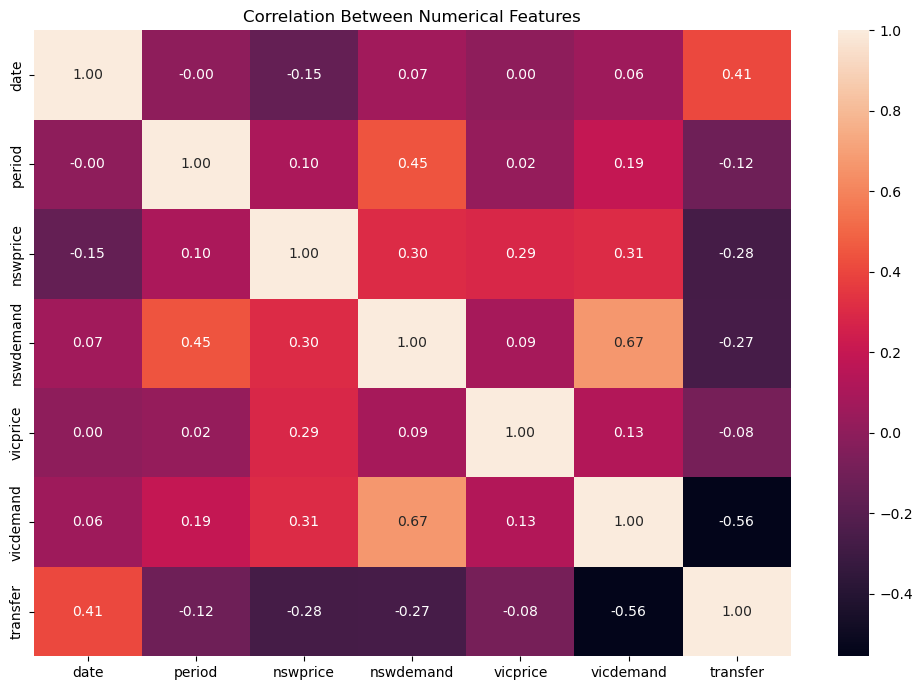

In [24]:
# Create a heatmap to make the feature relationships easier to compare
plt.figure(figsize=(10, 7))
sns.heatmap(feature_correlation, annot=True, fmt=".2f")

# Add a title to the correlation plot
plt.title("Correlation Between Numerical Features")

# Keep the plot layout clean
plt.tight_layout()

# Save the figure as a project artifact
plt.savefig("../reports/figures/feature_correlation.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

### Finding

The feature analysis provides an initial view of how the numerical predictors behave across the `UP` and `DOWN` classes and how strongly the predictors are related to one another.

The numerical features are already normalized to the 0–1 range, so I do not need to apply another general scaling transformation at this stage.

Some predictors may show relationships with one another. However, I will not remove features based only on correlation because their actual usefulness should be evaluated through the baseline and streaming experiments.

### Decision

I will retain the available predictor variables for the baseline stage.

I will treat `day` as categorical information and `class` strictly as the target variable. I will also preserve the original row ordering because it represents the data stream that DriftGuard will process later.

Any further feature-selection decision will be supported by model performance rather than exploratory analysis alone.

## Preprocessing Decisions

### Why

I have completed the initial data validation and exploratory analysis. I now need to convert the dataset into a representation that can be used by the classification models.

I want to make these changes carefully because DriftGuard will process the observations sequentially. I should prepare the features without changing their original order or introducing information from future observations.

### Decisions

- I will keep the numerical features in their existing normalized form.
- I will treat `day` as categorical information rather than as an ordinal numerical value.
- I will convert `day` into one-hot encoded features so that the model does not assume that one day is numerically closer to another.
- I will keep `date` and `period` as available predictors at this stage because they contain temporal information that may be useful for classification.
- I will keep `class` as the target and convert it into numerical labels for model development.
- I will not randomly shuffle the observations.

In [25]:
# Create a separate modeling copy so the cleaned dataset remains available for reference
model_data = df_clean.copy()

# Convert the day categories into separate binary features
model_data = pd.get_dummies(model_data, columns=["day"], dtype=int)

# Convert the target classes into numerical labels for model training
model_data["class"] = model_data["class"].map({"DOWN": 0, "UP": 1})

# Display the first few rows of the model-ready data
model_data.head()

,date,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class,day_1,day_2,day_3,day_4,day_5,day_6,day_7
0,0.0,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912,1,0,1,0,0,0,0,0
1,0.0,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912,1,0,1,0,0,0,0,0
2,0.0,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912,1,0,1,0,0,0,0,0
3,0.0,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912,1,0,1,0,0,0,0,0
4,0.0,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912,0,0,1,0,0,0,0,0


# Key Findings and Decisions

I have now completed the initial validation and exploratory analysis of the Electricity dataset.

### Dataset

The dataset contains 45,312 observations and 9 original columns, including 8 predictors and the binary target `class`.

### Data Quality

I found no missing values or duplicate observations. Therefore, I did not need to perform missing-value imputation or duplicate removal.

### Target

The target contains two classes, `UP` and `DOWN`. The classes are reasonably balanced, although `DOWN` occurs more frequently. Because of this, I will evaluate the models using Accuracy together with F1-score and Recall.

### Feature Representation

The numerical predictors are already normalized between 0 and 1, so I will preserve their existing scale rather than applying another scaling transformation.

The `day` variable is categorical, so I converted it into one-hot encoded features. This avoids introducing an artificial numerical relationship between the days.

The `date` and `period` variables are retained as predictors at this stage because they provide temporal information that may contribute to classification.

### Streaming Considerations

The original order of the observations will be preserved throughout the project. I will not randomly shuffle the dataset because DriftGuard is designed to operate on sequential data.

The dataset itself is not pre-divided into batches. I will create sequential batches later when I build the streaming simulation.

### Final Decision

I now have a validated and model-ready representation of the dataset. I will use this representation as the starting point for the baseline experiments.

The batch size, KNN window size, and Page-Hinkley parameters are intentionally not fixed yet. These decisions will be made during the relevant experimental stages rather than being chosen arbitrarily.

## Next Phase

In the next notebook, I will establish baseline performance for Gaussian Naive Bayes and KNN.

These baseline results will provide a reference point against which I can later evaluate incremental learning, drift detection, and adaptive model behaviour.